To confirm expectations about how model parameters affect behavior, we can plot simulations of behavioral benchmarks  across a range of parameter values.

In [1]:
import inspect
import json
import os
import warnings
from pathlib import Path
from typing import Any, Mapping, Sequence, cast, Type

import jax.numpy as jnp
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, display
from jax import random
from matplotlib import rcParams  # type: ignore

from jaxcmr import repetition
from jaxcmr.helpers import (
    format_floats,
    find_project_root,
    generate_trial_mask,
    import_from_string,
    load_data,
)
from jaxcmr.simulation import parameter_shifted_simulate_h5_from_h5
from jaxcmr.summarize import summarize_parameters
from jaxcmr.typing import RecallDataset

warnings.filterwarnings("ignore")

def save_figure(figure_dir, figure_str, suffix=None):
    plt.tight_layout()
    if not figure_str:
        plt.show()
        return
    os.makedirs(figure_dir, exist_ok=True)
    suffix_str = f"_{suffix}" if suffix else ""
    figure_path = os.path.join(figure_dir, f"{figure_str}{suffix_str}.png")
    plt.savefig(figure_path, bbox_inches="tight", dpi=600)
    plt.show()


Parameter Setup

In [2]:
# Run configuration
base_run_tag = "fixed_term"
experiment_count = 10
max_subjects = 0

# Data parameters
base_data_tag = "HealeyKahana2014"
data_tag = "HealeyKahana2014"
data_path = "data/HealeyKahana2014.h5"
figure_dir = "results/figures"
figure_str = ""
embedding_path = ""#"data/peers-all-mpnet-base-v2.npy"
emotion_feature_path = ""#"data/emotion_features_7col.npy"
feature_column = 6
concat_features = False
trial_query = "data['listtype'] == -1"
target_directory = "results/"

# algorithm selection
model_name = "WeirdCMRNoStop"
make_factory_path = "jaxcmr.models.cmr.make_factory"

component_paths = {
    "mfc_create_fn": "jaxcmr.components.linear_memory.init_mfc",
    "mcf_create_fn": "jaxcmr.components.linear_memory.init_mcf",
    "context_create_fn": "jaxcmr.components.context.init",
    "termination_policy_create_fn": "jaxcmr.components.termination.NoStopTermination",
}

sim_alg_path = "jaxcmr.simulation.simulate_study_free_recall_and_forced_stop"
loss_fn_path = "jaxcmr.loss.transform_sequence_likelihood.ExcludeTerminationLikelihoodLoss"
fit_alg_path = "jaxcmr.fitting.ScipyDE"
parameters = {
    "fixed": {
        "allow_repeated_recalls": False,
        "learn_after_context_update": False,
        "modulate_emotion_by_primacy": False,
    },
    "free": {
        "encoding_drift_rate": [2.220446049250313e-16, 0.9999999999999998],
        "start_drift_rate": [2.220446049250313e-16, 0.9999999999999998],
        "recall_drift_rate": [2.220446049250313e-16, 0.9999999999999998],
        "shared_support": [2.220446049250313e-16, 99.9999999999999998],
        "item_support": [2.220446049250313e-16, 99.9999999999999998],
        "learning_rate": [2.220446049250313e-16, 0.9999999999999998],
        "primacy_scale": [2.220446049250313e-16, 99.9999999999999998],
        "primacy_decay": [2.220446049250313e-16, 99.9999999999999998],
        "choice_sensitivity": [2.220446049250313e-16, 99.9999999999999998],
        # "emotion_attention": [2.220446049250313e-16, 9.9999999999999998],
        # "emotion_scale": [2.220446049250313e-16, 9.9999999999999998],
        # "lpp_scale": [2.220446049250313e-16, 9.9999999999999998],
        # "delay_drift_rate": [2.220446049250313e-16, 0.9999999999999998],
    },
}
# Parameter sweep
varied_parameter = 'start_drift_rate'
sweep_min = 0.
sweep_max = 1.
parameter_values = None
parameter_label_precision = 1

# Flow toggles
filter_repeated_recalls = True
handle_elis = False
redo_fits = False
require_existing_fit = False
redo_figures = True
redo_sims = False

# hyperparameters
seed = 0
relative_tolerance = 0.001
popsize = 15
num_steps = 1000
cross_rate = 0.9
diff_w = 0.85
best_of = 3

# analysis configuration
# Each config can optionally include:
# - trial_query: override the default trial query.
# - trial_queries: list of trial queries; one figure is generated per query.
# - trial_query_labels: labels used in multi-query figure suffixes.
comparison_analysis_configs = [
    #     {"target": "jaxcmr.analyses.cat_spc.plot_cat_spc", "figure_suffix": "cat_spc_negative", "kwargs": {"category_field": "condition", "category_values": [1]}},
    # {"target": "jaxcmr.analyses.cat_spc.plot_cat_spc", "figure_suffix": "cat_spc_neutral",  "kwargs": {"category_field": "condition", "category_values": [2]}},
    # {
    #     "target": "jaxcmr.analyses.nth_item_recall.plot_conditional_nth_item_recall_curve",
    #     "kwargs": {"query_study_position": 1},
    # },
    # {
    #     "target": "jaxcmr.analyses.nth_item_recall.plot_conditional_nth_item_recall_curve"
    # },
    # {"target": "jaxcmr.analyses.distcrp.plot_dist_crp"},
    # {"target": "jaxcmr.analyses.nth_item_recall.plot_simple_nth_item_recall_curve"},
    {"target": "jaxcmr.analyses.spc.plot_spc"},
    {"target": "jaxcmr.analyses.crp.plot_crp"},
    {"target": "jaxcmr.analyses.pnr.plot_pnr"},
    # {"target": "jaxcmr.analyses.termination_probability.plot_termination_probability"},
]


In [3]:
# derive run tag
from jaxcmr.typing import FittingAlgorithm, LossFn, TrialSimulator


run_tag = f"{base_run_tag}_best_of_{best_of}"
if max_subjects:
    run_tag += f"_nsubs_{max_subjects}"

# set up rng
rng = random.PRNGKey(seed)
project_root = Path(find_project_root())
figure_dir = os.path.join(project_root, figure_dir)

# add subdirectories for each product type: json, figures, h5
product_dirs = {}
for product, subdir in {"fits": "fits", "figures": "figures/shifting", "simulations": "simulations"}.items():
    product_dir = os.path.join(target_directory, subdir)
    product_dirs[product] = product_dir
    if not os.path.exists(product_dir):
        os.makedirs(product_dir)

# load data
data = load_data(os.path.join(project_root, data_path), max_subjects)
trial_mask = generate_trial_mask(data, trial_query)

# load feature blocks
semantic_features = None
if embedding_path:
    semantic_features = np.load(project_root / embedding_path).astype(np.float32)

categorical_column = None
if emotion_feature_path:
    emotion_features = np.load(project_root / emotion_feature_path).astype(np.float32)
    categorical_column = emotion_features[:, feature_column : feature_column + 1]

modeling_features = semantic_features
if concat_features:
    modeling_features = np.concatenate([categorical_column, semantic_features], axis=1)  # type: ignore

# import analyses
comparison_analyses = []
for config in comparison_analysis_configs:
    analysis_fn = import_from_string(config["target"])
    figure_suffix = config.get("figure_suffix")
    if figure_suffix is None:
        name = getattr(analysis_fn, "__name__", "analysis")
        figure_suffix = name[5:] if name.startswith("plot_") else name
    labels = tuple(cast(Sequence[str], config.get("labels", ())))
    contrast_name = config.get("contrast_name", varied_parameter)
    trial_query_override = config.get("trial_query")
    trial_queries_override = config.get("trial_queries")
    trial_query_labels = config.get("trial_query_labels")
    mixed_trial_query = config.get("mixed_trial_query")
    control_trial_query = config.get("control_trial_query")
    control_shuffles = config.get("control_shuffles", 1)
    control_seed = config.get("control_seed", 0)
    remove_control_repeats = config.get("remove_control_repeats", True)
    extra_kwargs = dict(cast(Mapping[str, Any], config.get("kwargs", {})))

    analysis_name = analysis_fn.__name__
    if "dist_" in analysis_name and semantic_features is not None:
        extra_kwargs.setdefault("features", semantic_features)
    elif "cat_" in analysis_name and categorical_column is not None:
        extra_kwargs.setdefault("features", categorical_column)

    comparison_analyses.append(
        {
            'target': analysis_fn,
            'figure_suffix': str(figure_suffix),
            'labels': labels,
            'contrast_name': str(contrast_name),
            'kwargs': extra_kwargs,
            'ylim': config.get('ylim', None),
            'trial_query': trial_query_override,
            'trial_queries': trial_queries_override,
            'trial_query_labels': trial_query_labels,
            'mixed_trial_query': mixed_trial_query,
            'control_trial_query': control_trial_query,
            'control_shuffles': control_shuffles,
            'control_seed': control_seed,
            'remove_control_repeats': remove_control_repeats,
        }
    )

# single_analyses = []
# for config in single_analysis_configs:
#     analysis_fn = import_from_string(config["target"])
#     figure_suffix = config.get("figure_suffix")
#     if figure_suffix is None:
#         name = getattr(analysis_fn, "__name__", "analysis")
#         figure_suffix = name[5:] if name.startswith("plot_") else name
#     labels = tuple(cast(Sequence[str], config.get("labels", ("Model",))))
#     contrast_name = config.get("contrast_name", "Source")
#     extra_kwargs = dict(cast(Mapping[str, Any], config.get("kwargs", {})))

#     analysis_name = analysis_fn.__name__
#     if "dist_" in analysis_name and semantic_features is not None:
#         extra_kwargs.setdefault("features", semantic_features)
#     elif "cat_" in analysis_name and categorical_column is not None:
#         extra_kwargs.setdefault("features", categorical_column)

#     single_analyses.append(
        # {
        #     'target': analysis_fn,
        #     'figure_suffix': str(figure_suffix),
        #     'labels': labels,
        #     'contrast_name': str(contrast_name),
        #     'kwargs': extra_kwargs,
        #     'ylim': config.get('ylim', None)
        # }
#     )

# configure model factory
make_factory = import_from_string(make_factory_path)
model_factory_cls = make_factory(
    **{key: import_from_string(path) for key, path in component_paths.items()}
)

# import fitting and simulation functions
fitting_algorithm_cls: Type[FittingAlgorithm] = import_from_string(fit_alg_path)
loss_fn_cls: Type[LossFn] = import_from_string(loss_fn_path)
simulate_trial_fn: TrialSimulator = import_from_string(sim_alg_path)

# derive list of query parameters from keys of `parameters`
query_parameters = list(parameters["free"].keys())

# make sure repeatedrecalls is in either both data_tag or data_path, or is in neither
if "repeatedrecalls" in data_tag.lower() or "repeatedrecalls" in data_path.lower():
    if (
        "repeatedrecalls" not in data_tag.lower()
        and "repeatedrecalls" not in data_path.lower()
    ):
        raise ValueError(
            "If 'repeatedrecalls' is in data_tag or data_path, it must be in both."
        )


def _resolve_trial_queries(analysis_cfg: Mapping[str, Any], default_query: str) -> list[str]:
    trial_queries = analysis_cfg.get("trial_queries")
    if trial_queries:
        return [str(query) for query in trial_queries]
    trial_query_override = analysis_cfg.get("trial_query")
    if trial_query_override:
        return [str(trial_query_override)]
    return [str(default_query)]


def _resolve_trial_query_labels(analysis_cfg: Mapping[str, Any], trial_queries: Sequence[str]) -> list[str]:
    labels = analysis_cfg.get("trial_query_labels")
    if labels:
        if len(labels) != len(trial_queries):
            raise ValueError("trial_query_labels must match trial_queries length")
        return [str(label) for label in labels]
    return [str(query) for query in trial_queries]


def _format_query_suffix(label: str, index: int) -> str:
    clean = "".join(ch if ch.isalnum() else "_" for ch in label)
    clean = "_".join([part for part in clean.split("_") if part])
    return clean if clean else f"query_{index + 1}"


Fit Model

In [4]:
fit_path = Path(product_dirs["fits"]) / f"{data_tag}_{model_name}_{run_tag}.json"
metadata = {
    "run_tag": run_tag,
    "data_tag": data_tag,
    "trial_query": trial_query,
    "model": model_name,
    "name": f"{data_tag}_{model_name}_{run_tag}",
    "components": component_paths,
    "fit_algorithm": fit_alg_path,
    "loss_function": loss_fn_path,
    "model_factory": make_factory_path,
    "embedding_path": embedding_path,
    "emotion_feature_path": emotion_feature_path,
    "feature_column": str(feature_column),
    "concat_features": str(concat_features),
}

if fit_path.exists() and not redo_fits:
    with fit_path.open() as handle:
        results = json.load(handle)
    if "subject" not in results["fits"]:
        results["fits"]["subject"] = results.get("subject", [])
    results |= metadata

elif not redo_fits and require_existing_fit:
    raise FileNotFoundError(
        f"Fit file not found at {fit_path}. "
        "Set redo_fits=True to fit, or correct target_directory/data_tag/model_name/run_tag."
    )

else:
    fitter = fitting_algorithm_cls(
        data,
        modeling_features,
        parameters["fixed"],
        model_factory_cls,
        loss_fn_cls,
        hyperparams={
            "num_steps": num_steps,
            "pop_size": popsize,
            "relative_tolerance": relative_tolerance,
            "cross_over_rate": cross_rate,
            "diff_w": diff_w,
            "progress_bar": True,
            "display_iterations": False,
            "best_of": best_of,
            "bounds": parameters["free"],
        },
    )

    results = fitter.fit(trial_mask) | metadata
    with fit_path.open("w") as handle:
        json.dump(results, handle, indent=4)

print(
    summarize_parameters([results], query_parameters, include_std=True, include_ci=True)
)


| Parameter | Statistic | HealeyKahana2014 WeirdCMRNoStop fixed term best of 3 |
|---|---|---|
| fitness | mean | 525.19 +/- 17.15 |
|  | std | 96.91 |
|  | min | 252.29 |
|  | max | 743.71 |
| encoding drift rate | mean | 0.80 +/- 0.02 |
|  | std | 0.13 |
|  | min | 0.18 |
|  | max | 0.99 |
| start drift rate | mean | 0.13 +/- 0.03 |
|  | std | 0.15 |
|  | min | 0.00 |
|  | max | 0.81 |
| recall drift rate | mean | 0.85 +/- 0.02 |
|  | std | 0.11 |
|  | min | 0.56 |
|  | max | 1.00 |
| shared support | mean | 9.14 +/- 2.16 |
|  | std | 12.18 |
|  | min | 0.02 |
|  | max | 84.13 |
| item support | mean | 19.63 +/- 4.32 |
|  | std | 24.40 |
|  | min | 0.01 |
|  | max | 99.91 |
| learning rate | mean | 0.28 +/- 0.04 |
|  | std | 0.24 |
|  | min | 0.00 |
|  | max | 1.00 |
| primacy scale | mean | 18.73 +/- 4.60 |
|  | std | 25.97 |
|  | min | 0.65 |
|  | max | 99.22 |
| primacy decay | mean | 17.01 +/- 4.57 |
|  | std | 25.82 |
|  | min | 0.00 |
|  | max | 85.62 |
| choice sensitivity | m

Simulate From Fit

In [5]:
# # Extend list length from 16 to 20 (add more interference items)
# n_trials = data['pres_itemnos'].shape[0]
# target_list_length = 22

# # Update listLength array
# data['listLength'] = np.full_like(data['listLength'], target_list_length)

# # Create new pres_itemnos: each row is 1-20
# data['pres_itemnos'] = np.tile(np.arange(1, target_list_length + 1), (n_trials, 1))

# # Zero-pad recalls to N x 20
# current_recall_length = data['recalls'].shape[1]
# if current_recall_length < target_list_length:
#     padding = np.zeros((n_trials, target_list_length - current_recall_length), dtype=data['recalls'].dtype)
#     data['recalls'] = np.concatenate([data['recalls'], padding], axis=1)

# print(f"pres_itemnos shape: {data['pres_itemnos'].shape}")
# print(f"recalls shape: {data['recalls'].shape}")
# print(f"listLength: {data['listLength'][:5]}")

In [6]:
# either load or perform model simulations

rng, rng_iter = random.split(rng)
params = {key: jnp.array(val) for key, val in results["fits"].items()}  # type: ignore
params[varied_parameter] = jnp.ones_like(params["encoding_drift_rate"])

if parameter_values is not None:
    considered_values = list(parameter_values)
else:
    if sweep_min == sweep_max:
        sweep_min, sweep_max = parameters['free'][varied_parameter]
    color_cycle = [each["color"] for each in rcParams["axes.prop_cycle"]]
    considered_values = jnp.linspace(
            start=sweep_min,
            stop=sweep_max,
            num=len(color_cycle)
        )[:-1].tolist()  # Remove the last value for consistency

if redo_sims or redo_figures:
    sim = parameter_shifted_simulate_h5_from_h5(
        model_factory_cls=model_factory_cls,
        dataset=data,
        features=modeling_features,
        parameters=params,
        trial_mask=trial_mask,
        experiment_count=experiment_count,
        varied_parameter=varied_parameter,
        parameter_values=considered_values,
        rng=rng_iter,
        simulate_trial_fn=simulate_trial_fn,
    )

    # Optional: reset subjects for uniformity across datasets
    for i in range(len(sim)):
        sim[i]["subject"] *= 0

        # Optionally filter repeated recalls in each simulated dataset
        if filter_repeated_recalls:
            sim[i]['recalls'] = repetition.filter_repeated_recalls(sim[i]['recalls'])
else:
    sim: RecallDataset = None # type: ignore



considered_values


[0.0,
 0.1111111119389534,
 0.2222222238779068,
 0.3333333432674408,
 0.4444444477558136,
 0.5555555820465088,
 0.6666666865348816,
 0.7777777910232544,
 0.8888888955116272]

Figures

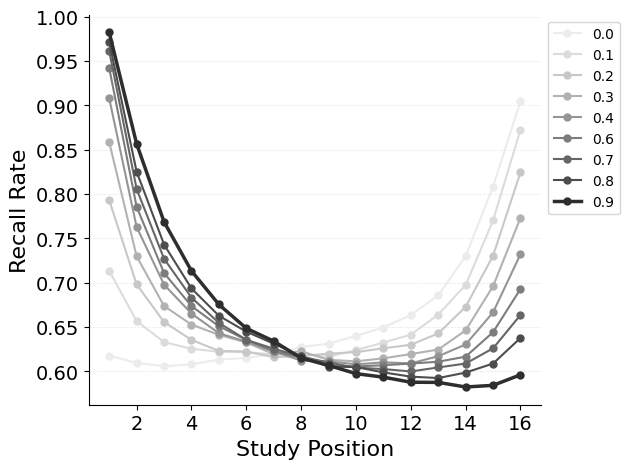

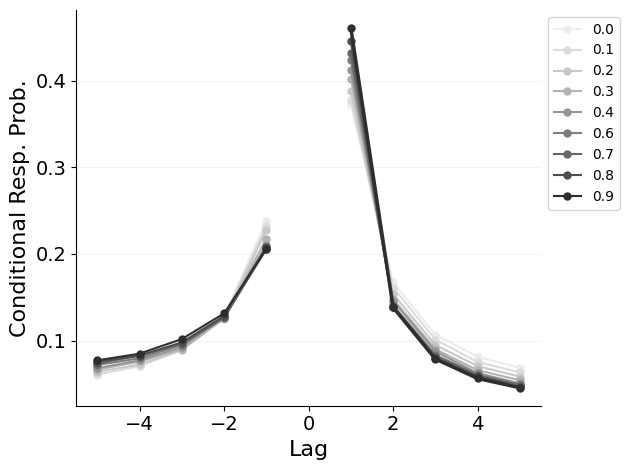

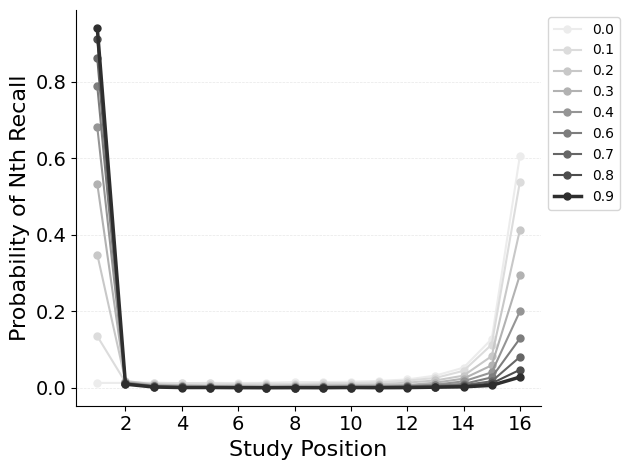

In [7]:
# generate figures comparing model and data
control_dataset_cache = {}

for analysis_cfg in comparison_analyses:
    analysis_fn = analysis_cfg["target"]
    analysis_suffix = analysis_cfg["figure_suffix"]
    trial_queries = _resolve_trial_queries(analysis_cfg, trial_query)
    trial_query_labels = _resolve_trial_query_labels(analysis_cfg, trial_queries)

    for query_index, (query, query_label) in enumerate(zip(trial_queries, trial_query_labels)):
        query_analysis_suffix = analysis_suffix
        if len(trial_queries) > 1:
            query_suffix = _format_query_suffix(query_label, query_index)
            query_analysis_suffix = f"{analysis_suffix}_{query_suffix}"

        figure_path = (
            os.path.join(
                figure_dir,
                f"{figure_str}_{query_analysis_suffix}_shift_{varied_parameter}.png",
            )
            if figure_str
            else None
        )
        if figure_path:
            print(f"![]({figure_path})")

        if figure_path and os.path.exists(figure_path) and not redo_figures:
            display(Image(filename=figure_path))
            continue

        # Create a color cycle using a continuous colormap
        cmap = plt.get_cmap("Greys")
        n_vals = len(considered_values)
        eps = 0.15
        color_cycle = [cmap(x) for x in np.linspace(eps, 1 - eps, n_vals)]
        color_cycle = [mcolors.rgb2hex(c) for c in color_cycle]

        control_trial_query = analysis_cfg.get("control_trial_query")
        use_control_dataset = control_trial_query is not None and query == str(control_trial_query)
        plot_query = query
        plot_datasets = sim
        if use_control_dataset:
            mixed_trial_query = analysis_cfg.get("mixed_trial_query")
            if mixed_trial_query is None:
                mixed_trial_query = trial_queries[0]
            control_cache_key = (
                str(mixed_trial_query),
                str(control_trial_query),
                int(analysis_cfg.get("control_shuffles", 1)),
                int(analysis_cfg.get("control_seed", 0)),
                bool(analysis_cfg.get("remove_control_repeats", True)),
            )
            if control_cache_key not in control_dataset_cache:
                control_dataset_cache[control_cache_key] = [
                    repetition.make_control_dataset(
                        dataset,
                        str(mixed_trial_query),
                        str(control_trial_query),
                        int(analysis_cfg.get("control_shuffles", 1)),
                        remove_repeats=bool(analysis_cfg.get("remove_control_repeats", True)),
                        seed=int(analysis_cfg.get("control_seed", 0)),
                    )
                    for dataset in sim
                ]
            plot_datasets = control_dataset_cache[control_cache_key]
            plot_query = str(mixed_trial_query)

        sim_trial_masks = [generate_trial_mask(dataset, plot_query) for dataset in plot_datasets]
        labels = list(analysis_cfg["labels"])
        if not labels:
            labels = format_floats(considered_values, parameter_label_precision)

        base_kwargs = {
            "datasets": plot_datasets,
            "trial_masks": [np.array(mask) for mask in sim_trial_masks],
            "color_cycle": color_cycle,
            "labels": labels,
            "contrast_name": analysis_cfg["contrast_name"],
            "axis": None,
        }
        base_kwargs |= analysis_cfg["kwargs"]

        signature = inspect.signature(analysis_fn)
        filtered_kwargs = {
            name: value
            for name, value in base_kwargs.items()
            if name in signature.parameters
        }

        axis = analysis_fn(**filtered_kwargs)
        axis.get_lines()[-1].set_linewidth(2.5)

        # Format the plot (font sizes, legend location, etc.)
        axis.tick_params(labelsize=14)
        axis.set_xlabel(axis.get_xlabel(), fontsize=16)
        axis.set_ylabel(axis.get_ylabel(), fontsize=16)
        axis.legend(loc="upper left", bbox_to_anchor=(1, 1))

        if analysis_cfg["ylim"] is not None:
            axis.set_ylim(analysis_cfg["ylim"])

        save_figure(
            figure_dir,
            figure_str,
            suffix=f"{query_analysis_suffix}_shift_{varied_parameter}",
        )
